In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import hashlib
import random
from tqdm import tqdm
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance, ImageOps
import cv2
import matplotlib.pyplot as plt

#Gathering Data

Dataset NutriVision dikumpulkan dari 3 sumber dataset publik di Kaggle yang digabungkan menjadi satu dataset terpadu:

1. Fruit and Vegetable Image Recognition (https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition)
2. Ingredients Bahan Makanan Image (https://www.kaggle.com/datasets/byrux12/ingredients-bahan-makanan-image-gambar)
3. Dataset Bahan Makanan Mentah (https://www.kaggle.com/datasets/efanfitriyan/dataset-bahan-makanan-mentah)

Karena berasal dari sumber yang berbeda, sebagian label masih menggunakan bahasa Inggris sehingga dilakukan penerjemahan secara manual ke bahasa Indonesia melalui Google Drive agar penamaan label konsisten.

Proses penggabungan dilakukan secara otomatis menggunakan script Python yang menelusuri seluruh subfolder dari masing-masing sumber, mengekstrak nama label dari struktur direktori, dan menyalin file gambar ke folder tujuan dengan penamaan yang seragam. Selain itu, pada tahap ini juga dilakukan pengecekan hash MD5 untuk memastikan tidak ada gambar yang terduplikasi sejak awal penggabungan, sehingga dataset raw yang dihasilkan sudah bersih dari duplikat antar sumber.

In [ ]:
source_dirs = [
    "/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset mentah",
    "/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset makanan",
    "/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset buah sayur"
]

target_dir = "/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw"
os.makedirs(target_dir, exist_ok=True)

In [ ]:
def get_hash(file_path):
  with open(file_path, 'rb') as f:
    return hashlib.md5(f.read()).hexdigest()

In [ ]:
def get_label_from_path(path):
    parts = path.split(os.sep)

    ignore = ['train', 'test', 'valid', 'val']

    for part in reversed(parts):
        if part.lower() not in ignore:
            return part.lower()

    return "unknown"

In [ ]:
seen_hashes = set()
total_copied = 0

for folder in source_dirs:
    print(f"Processing: {folder}")

    for root, dirs, files in os.walk(folder):
        for file in tqdm(files):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):

                file_path = os.path.join(root, file)

                try:
                    # cek duplicate
                    file_hash = get_hash(file_path)
                    if file_hash in seen_hashes:
                        continue

                    seen_hashes.add(file_hash)

                    # ambil label
                    label = get_label_from_path(root)

                    target_label_dir = os.path.join(target_dir, label)
                    os.makedirs(target_label_dir, exist_ok=True)

                    # rename
                    new_name = f"{label}_{total_copied}.jpg"

                    shutil.copy(file_path, os.path.join(target_label_dir, new_name))
                    total_copied += 1

                except Exception as e:
                    print(f"Error: {e}")

print(f"\nTotal images merged: {total_copied}")

Processing: /content/drive/MyDrive/DATASET CITRA MAKANAN/dataset mentah


0it [00:00, ?it/s]
100%|██████████| 500/500 [00:21<00:00, 23.09it/s]


Processing: /content/drive/MyDrive/DATASET CITRA MAKANAN/dataset makanan


0it [00:00, ?it/s]
100%|██████████| 500/500 [00:22<00:00, 22.41it/s]


Processing: /content/drive/MyDrive/DATASET CITRA MAKANAN/dataset buah sayur


0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 68/68 [00:30<00:00,  2.20it/s]
0it [00:00, ?it/s]
100%|██████████| 10/10 [00:03<00:00,  2.76it/s]
0it [00:00, ?it/s]
100%|██████████| 10/10 [00:03<00:00,  2.53it/s]


Total images merged: 8617


#Assesing Data

Tahap assessing data bertujuan untuk memahami kondisi awal dataset sebelum masuk ke proses cleaning dan preprocessing. Pada tahap ini dilakukan serangkaian pengecekan untuk mendeteksi potensi masalah kualitas data seperti file corrupt, duplikasi, format tidak valid, dan ukuran gambar yang tidak wajar. Hasil dari tahap ini menjadi dasar keputusan dalam menentukan langkah cleaning yang diperlukan.

In [ ]:
#Memasukkan dataset hasil gabungan dan olah manual

raw_path = "/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw"

##Cek jumlah gambar per label

Pengecekan jumlah gambar per label dilakukan untuk memahami distribusi awal dataset sebelum proses apapun diterapkan. Tujuannya adalah untuk mengidentifikasi apakah terdapat ketidakseimbangan jumlah data antar kelas (class imbalance) yang dapat berdampak negatif pada proses pelatihan model. Kelas dengan jumlah data yang terlalu sedikit berpotensi menyebabkan model tidak mampu mengenali kelas tersebut dengan baik, sementara kelas dengan data terlalu banyak dapat mendominasi proses pembelajaran.

In [ ]:
data_count = {}

for folder in os.listdir(raw_path):
    folder_path = os.path.join(raw_path, folder)

    if os.path.isdir(folder_path):
        images = [f for f in os.listdir(folder_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        data_count[folder] = len(images)

for label, count in data_count.items():
    print(f"{label}: {count} gambar")

daging sapi: 500 gambar
durian: 487 gambar
daging ayam: 481 gambar
tomat: 579 gambar
bawang putih: 499 gambar
bawang merah: 431 gambar
lemon: 76 gambar
kiwi: 84 gambar
lobak: 91 gambar
kedelai: 95 gambar
apel: 71 gambar
wortel: 78 gambar
semangka: 80 gambar
udang: 500 gambar
telur: 454 gambar
ikan: 494 gambar
kubis: 82 gambar
pisang: 73 gambar
timun: 86 gambar
cabai: 587 gambar
selada: 92 gambar
tempe: 490 gambar
tahu: 474 gambar
kentang: 73 gambar
delima: 75 gambar
bayam: 90 gambar
jagung: 154 gambar
kacang polong: 92 gambar
pir: 81 gambar
paprika: 169 gambar
jeruk: 65 gambar
mangga: 76 gambar
jahe: 65 gambar
anggur: 95 gambar
terong: 78 gambar
kembang kol: 75 gambar
bit: 78 gambar


In [ ]:
df = pd.DataFrame(list(data_count.items()), columns=['Label', 'Jumlah'])
df = df.sort_values(by='Jumlah', ascending=False)

In [ ]:
df

,Label,Jumlah
19,cabai,587
3,tomat,579
0,daging sapi,500
13,udang,500
4,bawang putih,499
15,ikan,494
21,tempe,490
1,durian,487
2,daging ayam,481
22,tahu,474


Dari hasil pengecekan, dataset raw terdiri dari 37 label dengan total 8.560 gambar. Distribusi data antar label sangat tidak merata, label dengan data terbanyak adalah cabai (587 gambar) dan tomat (579 gambar), sementara label dengan data paling sedikit adalah jeruk dan jahe (masing-masing 65 gambar). Selisih antara label terbanyak dan tersedikit mencapai 522 gambar, yang menunjukkan adanya class imbalance yang cukup signifikan pada dataset raw.

Ketidakseimbangan ini wajar terjadi pada dataset yang dikumpulkan dari berbagai sumber, karena setiap sumber memiliki jumlah data yang berbeda untuk setiap kategori. Kondisi ini akan ditangani pada tahap augmentasi dan balancing agar seluruh kelas memiliki representasi data yang merata sebelum digunakan untuk pelatihan model.

Selain itu, dari 37 label yang tersedia akan dilakukan seleksi untuk mempertahankan hanya 20 label yang paling relevan dengan kebutuhan sistem NutriVision, sehingga dataset akhir akan lebih terfokus dan efisien untuk proses modeling.

##Cek valid file / corrupt

Pengecekan file valid dan corrupt dilakukan untuk memastikan bahwa seluruh file gambar dalam dataset dapat dibuka dan dibaca dengan benar oleh library pengolah citra. File yang corrupt atau rusak tidak dapat diproses pada tahap selanjutnya dan berpotensi menyebabkan error saat pelatihan model. Deteksi dilakukan dengan mencoba membuka dan memuat setiap file menggunakan PIL, jika gagal, file tersebut dikategorikan sebagai corrupt dan dicatat untuk evaluasi lebih lanjut.

In [ ]:
corrupt_files = []

total_files = 0
valid_files = 0
invalid_files = 0

for folder in os.listdir(raw_path):
    folder_path = os.path.join(raw_path, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)

            try:
                img = Image.open(file_path)
                img.load()

                valid_files += 1
            except:
                corrupt_files.append(file_path)
                invalid_files += 1

            total_files += 1

print("=== HASIL CEK DATASET ===")
print(f"Total file       : {total_files}")
print(f"File valid       : {valid_files}")
print(f"File tidak valid : {invalid_files}")

print("\nContoh file error:")
for f in corrupt_files[:10]:
    print(f)

=== HASIL CEK DATASET ===
Total file       : 8150
File valid       : 8150
File tidak valid : 0

Contoh file error:


##Cek Duplikat

Pengecekan duplikat bertujuan untuk mendeteksi adanya gambar yang identik dalam dataset, baik duplikat dalam satu label maupun antar label berbeda. Duplikasi data dalam machine learning dapat menyebabkan model menjadi bias karena pola yang sama dipelajari berulang kali (redundansi), yang pada akhirnya menurunkan kemampuan generalisasi model terhadap data baru. Deteksi dilakukan dengan membandingkan nilai hash MD5 dari setiap file dua file dengan hash yang sama dianggap identik meskipun memiliki nama file yang berbeda.

In [ ]:
hash_dict = {}
duplicate_files = []

def get_hash(file_path):
    with open(file_path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

for folder in os.listdir(raw_path):
    folder_path = os.path.join(raw_path, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):

            if not file.lower().endswith(('.jpg','.jpeg','.png')):
                continue

            file_path = os.path.join(folder_path, file)

            try:
                file_hash = get_hash(file_path)

                if file_hash in hash_dict:
                    duplicate_files.append(file_path)
                else:
                    hash_dict[file_hash] = file_path

            except:
                print("Error:", file_path)

print("=== HASIL CEK DUPLIKAT ===")
print(f"Total file duplikat: {len(duplicate_files)}")

print("\nContoh duplikat:")
for f in duplicate_files[:10]:
    print(f)

=== HASIL CEK DUPLIKAT ===
Total file duplikat: 10

Contoh duplikat:
/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw/bawang putih/Salinan garlic_16089.jpg
/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw/bawang putih/Salinan garlic_16087.jpg
/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw/bawang putih/Salinan garlic_16091.jpg
/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw/bawang putih/Salinan garlic_16093.jpg
/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw/bawang putih/Salinan garlic_16086.jpg
/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw/bawang putih/Salinan garlic_16094.jpg
/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw/bawang putih/Salinan garlic_16092.jpg
/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw/bawang putih/Salinan garlic_16090.jpg
/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw/bawang putih/Salinan garlic_16088

Dari hasil pengecekan, ditemukan 10 file duplikat dalam dataset raw, seluruhnya berasal dari label bawang putih. File-file tersebut merupakan salinan (ditandai dengan prefix "Salinan") yang kemungkinan terjadi akibat proses penggandaan file secara tidak sengaja saat pengumpulan data dari Google Drive. Jumlah duplikat yang ditemukan tergolong sangat kecil hanya 0,12% dari total 8.560 gambar sehingga tidak berdampak signifikan terhadap kualitas dataset secara keseluruhan. Seluruh duplikat ini akan dihapus pada tahap cleaning.

##Cek format non image

Pengecekan format non-image dilakukan untuk memastikan bahwa seluruh file yang ada dalam dataset benar-benar merupakan file gambar dengan format yang didukung, yaitu JPG, JPEG, dan PNG. File dengan format lain seperti .txt, .csv, atau .xml yang mungkin ikut tersalin saat proses penggabungan dataset dapat menyebabkan error pada pipeline pemrosesan gambar. Pengecekan ini dilakukan berdasarkan ekstensi file.

In [ ]:
valid_ext = ('.jpg', '.jpeg', '.png')

non_image_files = []
total_checked = 0

for folder in os.listdir(raw_path):
    folder_path = os.path.join(raw_path, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            total_checked += 1

            if not file.lower().endswith(valid_ext):
                non_image_files.append(file_path)

print("=== HASIL CEK NON-IMAGE ===")
print(f"Total file dicek   : {total_checked}")
print(f"File non-image     : {len(non_image_files)}")

print("\nContoh file non-image:")
for f in non_image_files[:10]:
    print(f)

=== HASIL CEK NON-IMAGE ===
Total file dicek   : 8150
File non-image     : 0

Contoh file non-image:


##Cek ukuran gambar

Pengecekan ukuran gambar bertujuan untuk mengidentifikasi gambar yang memiliki dimensi tidak wajar terlalu kecil atau terlalu besar. Gambar yang terlalu kecil (di bawah 50x50 pixel) biasanya tidak mengandung detail visual yang cukup untuk dikenali oleh model, sehingga hanya akan menambah noise pada dataset. Sebaliknya, gambar yang terlalu besar (di atas 2000x2000 pixel) akan memperlambat proses pelatihan secara signifikan. Hasil pengecekan ini digunakan sebagai bahan pertimbangan dalam tahap cleaning, meskipun tidak selalu harus dihapus secara otomatis karena proses resize pada tahap preprocessing dapat menanganinya.

In [ ]:
small_images = []
large_images = []

total_checked = 0

for folder in os.listdir(raw_path):
    folder_path = os.path.join(raw_path, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):

            if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            file_path = os.path.join(folder_path, file)
            total_checked += 1

            try:
                img = Image.open(file_path)
                width, height = img.size

                if width < 50 or height < 50:
                    small_images.append((file_path, width, height))

                if width > 2000 or height > 2000:
                    large_images.append((file_path, width, height))

            except:
                pass

print("=== HASIL CEK UKURAN GAMBAR ===")
print(f"Total dicek        : {total_checked}")
print(f"Gambar terlalu kecil : {len(small_images)}")
print(f"Gambar terlalu besar : {len(large_images)}")

print("\nContoh gambar kecil:")
for f in small_images[:5]:
    print(f)

print("\nContoh gambar besar:")
for f in large_images[:5]:
    print(f)

=== HASIL CEK UKURAN GAMBAR ===
Total dicek        : 8150
Gambar terlalu kecil : 0
Gambar terlalu besar : 412

Contoh gambar kecil:

Contoh gambar besar:
('/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw/tomat/tomato_14773.jpg', 2329, 3500)
('/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw/tomat/tomato_14781.jpg', 1600, 2838)
('/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw/tomat/tomato_14780.jpg', 3000, 1995)
('/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw/tomat/tomato_14783.jpg', 2592, 3872)
('/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw/tomat/tomato_14786.jpg', 3872, 2592)


#Cleaning & Pre Process

Tahap cleaning dan preprocessing merupakan inti dari persiapan dataset sebelum digunakan untuk pelatihan model. Pada tahap ini dilakukan beberapa langkah utama: seleksi label yang relevan, penghapusan duplikat, augmentasi untuk menyeimbangkan distribusi data, dan standarisasi ukuran gambar melalui resize dengan padding. Setiap langkah memiliki tujuan spesifik untuk meningkatkan kualitas dan konsistensi dataset sehingga model dapat belajar secara optimal.

## Membuat folder untuk menyimpan prosess data

Sebelum melakukan proses cleaning, dataset raw disalin terlebih dahulu ke folder baru yang akan menjadi working directory selama proses berlangsung. Pendekatan ini penting untuk menjaga integritas dataset original. Seluruh perubahan seperti penghapusan file, augmentasi, dan resize hanya dilakukan pada salinan data, bukan pada dataset raw. Dengan demikian, jika terjadi kesalahan pada proses cleaning, dataset asli tetap aman dan proses dapat diulang dari awal tanpa kehilangan data.

In [ ]:
raw_path = "/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_capstone_raw"
processed_path = "/content/drive/MyDrive/DATASET CITRA MAKANAN/dataset_raw_clean"

# copy raw ke processed
shutil.copytree(raw_path, processed_path, dirs_exist_ok=True)

# semua proses pakai processed yang disimpan di dataset_path
dataset_path = processed_path

## Hapus Label tidak diperlukan

Dari 37 label yang tersedia pada dataset raw, dilakukan seleksi untuk mempertahankan label yang paling relevan dengan kebutuhan sistem NutriVision. Sebanyak 17 label dihapus dengan pertimbangan sebagai berikut:

- **Tumpang tindih kategori**: beberapa label seperti kedelai, kacang polong, dan jagung merupakan bahan mentah yang jarang dikonsumsi langsung dan sulit dibedakan secara visual dari kategori serupa.
- **Efisiensi modeling**: mempertahankan terlalu banyak kelas dengan jumlah data yang tidak merata dapat menurunkan performa model. Dengan mengurangi jumlah kelas menjadi 20, model dapat fokus belajar pada kategori makanan yang paling relevan dan sering ditemui.

Label yang dipertahankan mencakup bahan-bahan makanan pokok dan umum dalam masakan Indonesia seperti ayam, ikan, udang, tahu, tempe, serta berbagai sayuran dan buah yang mudah dikenali.

In [ ]:
hapus_labels = [
    "semangka",
    "lobak",
    "kedelai",
    "kentang",
    "delima",
    "bayam",
    "jagung",
    "kacang polong",
    "pir",
    "paprika",
    "jeruk",
    "anggur",
    "terong",
    "kembang kol",
    "bit",
    "jahe",
    "mangga"
]

for label in hapus_labels:
    path = os.path.join(dataset_path, label)

    if os.path.exists(path):
        shutil.rmtree(path)
        print("Dihapus:", label)

Dihapus: semangka
Dihapus: lobak
Dihapus: kedelai
Dihapus: kentang
Dihapus: delima
Dihapus: bayam
Dihapus: jagung
Dihapus: kacang polong
Dihapus: pir
Dihapus: paprika
Dihapus: jeruk
Dihapus: anggur
Dihapus: terong
Dihapus: kembang kol
Dihapus: bit
Dihapus: jahe
Dihapus: mangga


##Hapus Duplicate

Penghapusan duplikat dilakukan pada dataset yang sudah diseleksi labelnya. Meskipun pada tahap gathering sudah dilakukan pengecekan hash, duplikat masih mungkin muncul karena beberapa sumber dataset memiliki gambar yang sama namun dengan nama file berbeda. Proses penghapusan menggunakan pendekatan hash MD5. Setiap file yang memiliki hash identik dengan file yang sudah ada sebelumnya akan langsung dihapus dari direktori. Langkah ini penting untuk memastikan bahwa setiap gambar dalam dataset benar-benar unik sehingga model tidak mempelajari pola yang sama berulang kali.

In [ ]:
def get_hash(file_path):
    with open(file_path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

seen_hashes = set()
duplicate_count = 0

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(root, file)

            try:
                file_hash = get_hash(path)

                if file_hash in seen_hashes:
                    os.remove(path)
                    duplicate_count += 1
                else:
                    seen_hashes.add(file_hash)

            except:
                pass

print("Total duplicate removed:", duplicate_count)

Total duplicate removed: 10


##Augmentasi for balancing

Augmentasi data dilakukan untuk mengatasi ketidakseimbangan jumlah gambar antar kelas (class imbalance). Setelah seleksi label dan penghapusan duplikat, beberapa kelas memiliki jumlah data yang jauh lebih sedikit dibandingkan kelas lainnya. Kondisi ini dapat menyebabkan model cenderung lebih baik mengenali kelas dengan data banyak dan kurang optimal pada kelas dengan data sedikit.

Teknik augmentasi yang diterapkan mencakup tiga jenis transformasi:
- **Flip horizontal**: membalik gambar secara horizontal secara acak untuk menambah variasi orientasi.
- **Rotasi**: memutar gambar dengan sudut 90, 180, atau 270 derajat secara acak untuk mensimulasikan variasi sudut pengambilan gambar.
- **Brightness adjustment**: mengubah kecerahan gambar secara acak untuk mensimulasikan kondisi pencahayaan yang berbeda.

Proses balancing dilakukan dengan menambahkan gambar hasil augmentasi hingga setiap kelas memiliki jumlah data yang sama dengan kelas terbanyak, sehingga distribusi dataset menjadi sepenuhnya merata.

In [ ]:
before_counts = {}

for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)
    if os.path.isdir(label_path):
        before_counts[label] = len(os.listdir(label_path))

print("Distribusi sebelum augmentasi:")
print(before_counts)

Distribusi sebelum augmentasi:
{'daging sapi': 500, 'durian': 487, 'daging ayam': 481, 'tomat': 579, 'bawang putih': 489, 'bawang merah': 431, 'lemon': 76, 'kiwi': 84, 'apel': 71, 'wortel': 78, 'udang': 500, 'telur': 454, 'ikan': 494, 'kubis': 82, 'pisang': 73, 'timun': 86, 'cabai': 587, 'selada': 92, 'tempe': 490, 'tahu': 474}


In [ ]:
max_count = max(before_counts.values())
print("Target per class:", max_count)

Target per class: 587


In [ ]:
def augment_image(img):
    # random flip
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # random rotate
    angle = random.choice([90, 180, 270])
    img = img.rotate(angle)

    # random brightness
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.7, 1.3))

    return img

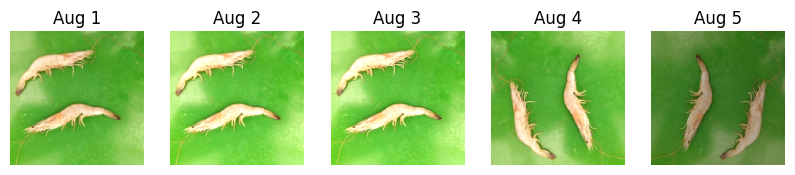

In [ ]:
def show_augmentations(image_path):
    img = Image.open(image_path)

    plt.figure(figsize=(10,5))

    for i in range(5):
        aug = augment_image(img)

        plt.subplot(1,5,i+1)
        plt.imshow(aug)
        plt.title(f"Aug {i+1}")
        plt.axis("off")

    plt.show()

sample_path = os.path.join(dataset_path, "udang", "udang_460.jpg")
show_augmentations(sample_path)

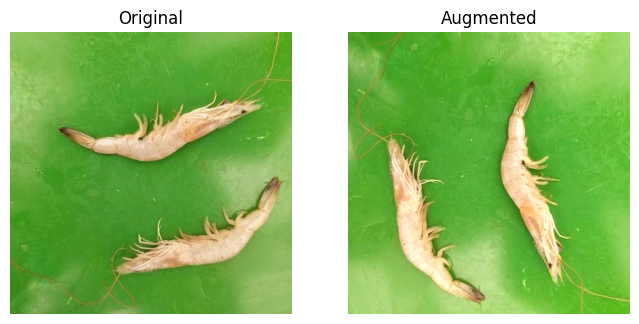

In [ ]:
img_pil = Image.open(sample_path)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img_pil)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(augment_image(img_pil))
plt.title("Augmented")
plt.axis("off")

plt.show()

In [ ]:
for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)

    if not os.path.isdir(label_path):
        continue

    images = os.listdir(label_path)
    current_count = len(images)

    print(f"{label}: {current_count}")

    while current_count < max_count:
        img_name = random.choice(images)
        img_path = os.path.join(label_path, img_name)

        try:
            img = Image.open(img_path)
            aug_img = augment_image(img)

            new_name = f"{label}_aug_{current_count}.jpg"
            aug_img.save(os.path.join(label_path, new_name))

            current_count += 1

        except:
            continue

print("Balancing selesai!")

daging sapi: 500
durian: 487
daging ayam: 481
tomat: 579
bawang putih: 489
bawang merah: 431
lemon: 76
kiwi: 84
apel: 71
wortel: 78
udang: 500
telur: 454
ikan: 494
kubis: 82
pisang: 73
timun: 86
cabai: 587
selada: 92
tempe: 490
tahu: 474
Balancing selesai!


In [ ]:
after_counts = {}

for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)
    if os.path.isdir(label_path):
        after_counts[label] = len(os.listdir(label_path))

after_counts

{'daging sapi': 587,
 'durian': 587,
 'daging ayam': 587,
 'tomat': 587,
 'bawang putih': 587,
 'bawang merah': 587,
 'lemon': 587,
 'kiwi': 587,
 'apel': 587,
 'wortel': 587,
 'udang': 587,
 'telur': 587,
 'ikan': 587,
 'kubis': 587,
 'pisang': 587,
 'timun': 587,
 'cabai': 587,
 'selada': 587,
 'tempe': 587,
 'tahu': 587}

##Resize

Standarisasi ukuran gambar menjadi 224x224 pixel dilakukan karena arsitektur model deep learning untuk klasifikasi citra umumnya memerlukan input dengan dimensi yang tetap dan seragam. Ukuran 224x224 dipilih karena merupakan standar input yang digunakan oleh berbagai arsitektur populer seperti VGG, ResNet, dan MobileNet.

Teknik yang digunakan adalah resize dengan padding berbasis mean color, bukan crop atau stretch. Pendekatan ini bekerja dengan cara:
1. Menghitung skala resize agar sisi terpanjang gambar menjadi tepat 224 pixel.
2. Menempatkan gambar yang sudah di-resize di tengah canvas 224x224.
3. Mengisi area kosong (padding) dengan warna rata-rata dari gambar asli.

Penggunaan mean color sebagai padding dipilih agar area kosong tidak mengganggu distribusi pixel secara signifikan, sekaligus menjaga rasio aspek asli gambar sehingga objek makanan tidak terdistorsi. Pendekatan ini lebih baik dibandingkan padding hitam yang dapat memperkenalkan bias berupa pixel bernilai 0 dalam jumlah besar.

In [ ]:
def resize_with_padding(img, size=224):

    h, w = img.shape[:2]

    scale = size / max(h, w)

    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(img, (new_w, new_h))

    mean_color = img.mean(axis=(0,1)).astype(np.uint8)

    canvas = np.ones((size, size, 3), dtype=np.uint8) * mean_color

    x_offset = (size - new_w) // 2
    y_offset = (size - new_h) // 2

    canvas[y_offset:y_offset+new_h,
           x_offset:x_offset+new_w] = resized

    return canvas

# PROCESS

for label in os.listdir(dataset_path):

    label_path = os.path.join(dataset_path, label)

    if not os.path.isdir(label_path):
        continue

    print(f"\nProcessing label: {label}")

    for file in sorted(os.listdir(label_path)):

        if file.lower().endswith(('.jpg', '.png', '.jpeg')):

            img_path = os.path.join(label_path, file)

            img = cv2.imread(img_path)

            if img is None:
                print(f"Gagal baca: {file}")
                continue

            # skip kalau sudah 224x224
            if img.shape[0] == 224 and img.shape[1] == 224:
                continue

            # resize + padding
            resized = resize_with_padding(img, size=224)

            # overwrite file lama
            cv2.imwrite(img_path, resized)

            print(f"{file} | {img.shape} -> {resized.shape}")


print("\n===== SEMUA GAMBAR SELESAI =====")

Output streaming akan dipotong hingga 5000 baris terakhir.
telur_801.jpg | (256, 256, 3) -> (224, 224, 3)
telur_802.jpg | (256, 256, 3) -> (224, 224, 3)
telur_803.jpg | (256, 256, 3) -> (224, 224, 3)
telur_804.jpg | (256, 256, 3) -> (224, 224, 3)
telur_805.jpg | (256, 256, 3) -> (224, 224, 3)
telur_806.jpg | (256, 256, 3) -> (224, 224, 3)
telur_807.jpg | (256, 256, 3) -> (224, 224, 3)
telur_808.jpg | (256, 256, 3) -> (224, 224, 3)
telur_809.jpg | (256, 256, 3) -> (224, 224, 3)
telur_810.jpg | (256, 256, 3) -> (224, 224, 3)
telur_811.jpg | (256, 256, 3) -> (224, 224, 3)
telur_812.jpg | (256, 256, 3) -> (224, 224, 3)
telur_813.jpg | (256, 256, 3) -> (224, 224, 3)
telur_814.jpg | (256, 256, 3) -> (224, 224, 3)
telur_815.jpg | (256, 256, 3) -> (224, 224, 3)
telur_816.jpg | (256, 256, 3) -> (224, 224, 3)
telur_817.jpg | (256, 256, 3) -> (224, 224, 3)
telur_818.jpg | (256, 256, 3) -> (224, 224, 3)
telur_819.jpg | (256, 256, 3) -> (224, 224, 3)
telur_820.jpg | (256, 256, 3) -> (224, 224, 3)
t

#Splitting Dataset

In [ ]:
import os
import shutil
import random
from pathlib import Path
from collections import defaultdict

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.20
TEST_RATIO  = 0.10
RANDOM_SEED = 42

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6, \
    "Rasio train + val + test harus = 1.0"

random.seed(RANDOM_SEED)

def create_split_dirs(output_dir, class_names):
    for split in ["train", "val", "test"]:
        for cls in class_names:
            Path(os.path.join(output_dir, split, cls)).mkdir(parents=True, exist_ok=True)

def split_dataset(dataset_dir, output_dir):
    dataset_path = Path(dataset_dir)
    class_dirs = sorted([d for d in dataset_path.iterdir() if d.is_dir()])

    if not class_dirs:
        print(f"[ERROR] Tidak ada subfolder ditemukan di '{dataset_dir}'")
        return

    class_names = [d.name for d in class_dirs]
    print(f"[INFO] Ditemukan {len(class_names)} class: {class_names}\n")

    create_split_dirs(output_dir, class_names)

    stats = defaultdict(lambda: {"train": 0, "val": 0, "test": 0})

    for class_dir in class_dirs:
        cls = class_dir.name
        images = [
            f for f in class_dir.iterdir()
            if f.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        ]
        random.shuffle(images)

        n = len(images)
        n_train = int(n * TRAIN_RATIO)
        n_val   = int(n * VAL_RATIO)
        n_test  = n - n_train - n_val

        splits = {
            "train": images[:n_train],
            "val":   images[n_train:n_train + n_val],
            "test":  images[n_train + n_val:],
        }

        for split_name, split_images in splits.items():
            dest_dir = Path(output_dir) / split_name / cls
            for img_path in split_images:
                shutil.copy2(img_path, dest_dir / img_path.name)
            stats[cls][split_name] = len(split_images)

    print(f"{'Class':<25} {'Total':>7} {'Train':>7} {'Val':>7} {'Test':>7}")
    print("-" * 55)
    grand_total = grand_train = grand_val = grand_test = 0
    for cls in class_names:
        total = sum(stats[cls].values())
        tr, va, te = stats[cls]["train"], stats[cls]["val"], stats[cls]["test"]
        print(f"{cls:<25} {total:>7} {tr:>7} {va:>7} {te:>7}")
        grand_total += total
        grand_train += tr
        grand_val   += va
        grand_test  += te

    print("-" * 55)
    print(f"{'TOTAL':<25} {grand_total:>7} {grand_train:>7} {grand_val:>7} {grand_test:>7}")
    print(f"\n[DONE] Dataset tersimpan di '{output_dir}/'")

if __name__ == "__main__":
    split_dataset(DATASET_DIR, OUTPUT_DIR)

# Pertanyaan Bisnis

1. Bagaimana mengevaluasi kualitas dan kesiapan dataset citra makanan melalui analisis distribusi jumlah data per kelas, deteksi duplikasi, serta karakteristik nilai pixel setelah preprocessing untuk mendukung tahap eksplorasi data pada sistem NutriVision?

2. Bagaimana mengidentifikasi ketidakseimbangan jumlah citra antar kelas serta mengevaluasi peran augmentasi dalam menyeimbangkan distribusi data untuk meningkatkan kualitas dataset citra makanan pada tahap eksplorasi?

3. Bagaimana teknik resize dengan padding mempengaruhi distribusi nilai pixel dan representasi visual citra makanan untuk memastikan kualitas preprocessing dalam dataset NutriVision pada tahap eksplorasi data?



#EDA


Exploratory Data Analysis (EDA) dilakukan untuk menjawab tiga pertanyaan bisnis utama yang menjadi fokus eksplorasi dataset NutriVision. EDA tidak hanya bertujuan memvalidasi hasil proses cleaning dan preprocessing, tetapi juga untuk memperoleh insight mendalam mengenai karakteristik dataset yang akan berpengaruh pada strategi modeling. Setiap visualisasi dirancang untuk memberikan pemahaman yang jelas dan terukur terhadap kondisi dataset dari berbagai aspek.

## Distribusi data setelah preprosessing

In [ ]:
after_counts = {}

for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)
    if os.path.isdir(label_path):
        after_counts[label] = len(os.listdir(label_path))

print("Distribusi data setelah preprocessing:")
print(after_counts)

Distribusi data setelah preprocessing:
{'daging sapi': 587, 'durian': 587, 'daging ayam': 587, 'tomat': 587, 'bawang putih': 587, 'bawang merah': 587, 'lemon': 587, 'kiwi': 587, 'apel': 587, 'wortel': 587, 'udang': 587, 'telur': 587, 'ikan': 587, 'kubis': 587, 'pisang': 587, 'timun': 587, 'cabai': 587, 'selada': 587, 'tempe': 587, 'tahu': 587}


## Jumlah dupikasi setelah preprosessing

In [ ]:
def get_hash(file_path):
    with open(file_path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = set()
duplicates = 0

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(root, file)
            try:
                file_hash = get_hash(path)
                if file_hash in hashes:
                    duplicates += 1
                else:
                    hashes.add(file_hash)
            except:
                pass

print("Jumlah duplikasi ditemukan:", duplicates)

Jumlah duplikasi ditemukan: 0


## Statistik nilai pixel

In [ ]:
pixel_values = []
sample_paths = []

# ambil sample gambar
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            sample_paths.append(os.path.join(root, file))

# ambil sample acak
sample_paths = random.sample(sample_paths, min(100, len(sample_paths)))

# ekstrak pixel
for path in sample_paths:
    try:
        img = Image.open(path)
        img_array = np.array(img)
        pixel_values.extend(img_array.flatten())
    except:
        pass

pixel_values = np.array(pixel_values)

print("\nStatistik Nilai Pixel (Setelah Preprocessing):")
print("Min:", pixel_values.min())
print("Max:", pixel_values.max())
print("Mean:", pixel_values.mean())
print("Std:", pixel_values.std())


Statistik Nilai Pixel (Setelah Preprocessing):
Min: 0
Max: 255
Mean: 131.76055883290817
Std: 87.45532439783538


## Distribusi label sebelum augmentaasi dan balancing

In [ ]:
print("Distribusi sebelum augmentasi:")
print(before_counts)

Distribusi sebelum augmentasi:
{'daging sapi': 500, 'durian': 487, 'daging ayam': 481, 'tomat': 579, 'bawang putih': 489, 'bawang merah': 431, 'lemon': 76, 'kiwi': 84, 'apel': 71, 'wortel': 78, 'udang': 500, 'telur': 454, 'ikan': 494, 'kubis': 82, 'pisang': 73, 'timun': 86, 'cabai': 587, 'selada': 92, 'tempe': 490, 'tahu': 474}


## Distribusi label setelah augmentaasi dan balancing

In [ ]:
after_counts = {}

for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)
    if os.path.isdir(label_path):
        after_counts[label] = len(os.listdir(label_path))

print("Distribusi setelah augmentasi:")
print(after_counts)

Distribusi setelah augmentasi:
{'daging sapi': 587, 'durian': 587, 'daging ayam': 587, 'tomat': 587, 'bawang putih': 587, 'bawang merah': 587, 'lemon': 587, 'kiwi': 587, 'apel': 587, 'wortel': 587, 'udang': 587, 'telur': 587, 'ikan': 587, 'kubis': 587, 'pisang': 587, 'timun': 587, 'cabai': 587, 'selada': 587, 'tempe': 587, 'tahu': 587}


## Perbandingan distribusi data antara sebelum dan setelah preprosessing

In [ ]:
print("\nPerbandingan Before vs After:")

for label in after_counts:
    before = before_counts.get(label, 0)
    after = after_counts.get(label, 0)
    print(f"{label}: {before} → {after}")


Perbandingan Before vs After:
daging sapi: 500 → 587
durian: 487 → 587
daging ayam: 481 → 587
tomat: 579 → 587
bawang putih: 489 → 587
bawang merah: 431 → 587
lemon: 76 → 587
kiwi: 84 → 587
apel: 71 → 587
wortel: 78 → 587
udang: 500 → 587
telur: 454 → 587
ikan: 494 → 587
kubis: 82 → 587
pisang: 73 → 587
timun: 86 → 587
cabai: 587 → 587
selada: 92 → 587
tempe: 490 → 587
tahu: 474 → 587


## Total keseluruhan gambar sebelum dan setelah prosessing

In [ ]:
total_before = sum(before_counts.values())
total_after = sum(after_counts.values())

print("\nTotal gambar sebelum augmentasi:", total_before)
print("Total gambar setelah augmentasi:", total_after)


Total gambar sebelum augmentasi: 6608
Total gambar setelah augmentasi: 11740


## Kualitas preprocessing resize dan padding

In [ ]:
records = []

for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)
    if not os.path.isdir(label_path):
        continue

    for fname in os.listdir(label_path):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        img = cv2.imread(os.path.join(label_path, fname))
        if img is None:
            continue

        h, w = img.shape[:2]

        # Proporsi padding terhadap canvas 224x224
        scale  = 224 / max(h, w)
        new_h  = int(h * scale)
        new_w  = int(w * scale)
        pad_pct = (224*224 - new_h*new_w) / (224*224) * 100

        records.append({
            'label'     : label,
            'pad_pct'   : round(pad_pct, 2),
            'brightness': round(float(img.mean()), 2),
            'std_pixel' : round(float(img.std()),  2),
            'mean_R'    : round(float(img[:,:,2].mean()), 2),
            'mean_G'    : round(float(img[:,:,1].mean()), 2),
            'mean_B'    : round(float(img[:,:,0].mean()), 2),
        })

df = pd.DataFrame(records)

# Ringkasan per label
summary = df.groupby('label').agg(
    n_gambar   = ('pad_pct',    'count'),
    pad_mean   = ('pad_pct',    'mean'),
    pad_max    = ('pad_pct',    'max'),
    brightness = ('brightness', 'mean'),
    std_pixel  = ('std_pixel',  'mean'),
    mean_R     = ('mean_R',     'mean'),
    mean_G     = ('mean_G',     'mean'),
    mean_B     = ('mean_B',     'mean'),
).round(2).reset_index()

print("===== RINGKASAN EDA PER LABEL =====")
print(summary.to_string(index=False))


===== RINGKASAN EDA PER LABEL =====
       label  n_gambar  pad_mean  pad_max  brightness  std_pixel  mean_R  mean_G  mean_B
        apel       587       0.0      0.0      118.42      65.65  138.75  115.96  100.55
bawang merah       587       0.0      0.0      159.31      81.30  188.14  142.64  147.16
bawang putih       587       0.0      0.0      168.66      68.77  184.75  171.15  150.09
       cabai       587       0.0      0.0      123.49      84.11  159.49  122.64   88.35
 daging ayam       587       0.0      0.0      184.91      71.14  203.72  183.25  167.76
 daging sapi       587       0.0      0.0      122.51      48.50  141.93  116.11  109.49
      durian       587       0.0      0.0      134.92      61.99  159.20  145.22  100.32
        ikan       587       0.0      0.0      124.02      44.11  124.64  127.17  120.26
        kiwi       587       0.0      0.0      122.49      64.12  136.93  137.53   93.01
       kubis       587       0.0      0.0      117.30      58.86  117.88  

# Visualisasi dan Explanatory

## 1. Bagaimana mengevaluasi kualitas dan kesiapan dataset citra makanan melalui analisis distribusi jumlah data per kelas, deteksi duplikasi, serta karakteristik nilai pixel setelah preprocessing untuk mendukung tahap eksplorasi data pada sistem NutriVision?

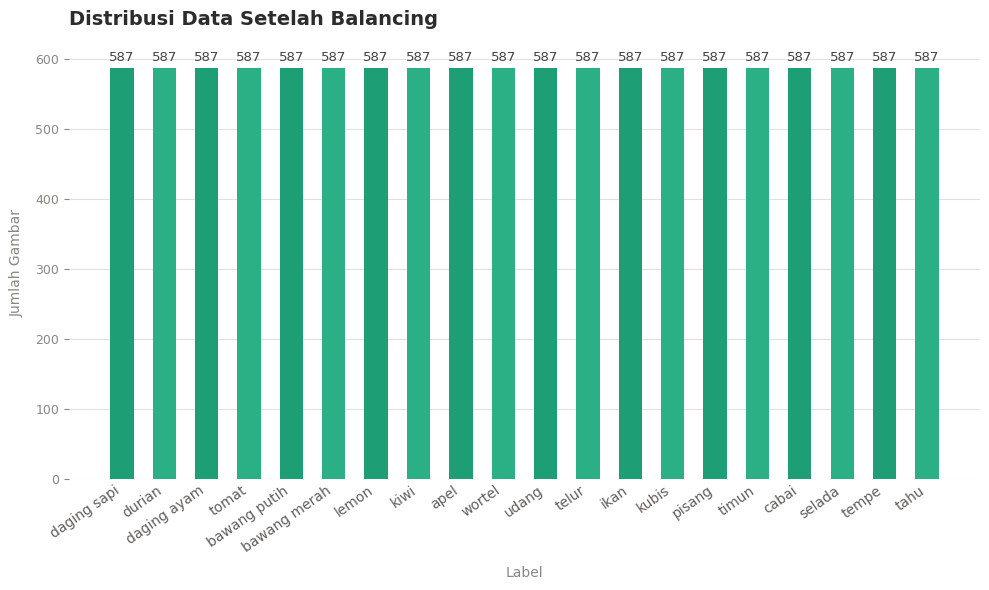

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

labels = list(after_counts.keys())
values = list(after_counts.values())
x = np.arange(len(labels))

bar_colors = ['#1D9E75' if i % 2 == 0 else '#2BAF84' for i in range(len(labels))]

bars = ax.bar(x, values, color=bar_colors, width=0.55,
              edgecolor='none', zorder=3)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.008,
            f'{val:,}',
            ha='center', va='bottom',
            color='#444441', fontsize=9.5)

ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right',
                   color='#5F5E5A', fontsize=10)
ax.tick_params(axis='y', colors='#888780', labelsize=9)
ax.tick_params(axis='x', length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title('Distribusi Data Setelah Balancing',
             color='#2C2C2A', fontsize=14, fontweight='bold',
             pad=16, loc='left')
ax.set_xlabel('Label', color='#888780', fontsize=10, labelpad=8)
ax.set_ylabel('Jumlah Gambar', color='#888780', fontsize=10, labelpad=8)

plt.tight_layout()
plt.show()

Insight:

Berdasarkan visualisasi distribusi data setelah balancing, terlihat bahwa seluruh label makanan memiliki jumlah citra yang identik, yaitu sebanyak 587 gambar pada setiap kelas. Tidak terdapat perbedaan tinggi bar antar label, yang menunjukkan bahwa proses balancing berhasil menghasilkan distribusi data yang sepenuhnya merata pada seluruh kategori makanan.

Seluruh label memiliki representasi jumlah data yang sama sehingga tidak terdapat kelas mayoritas maupun minoritas pada dataset. Kondisi ini menunjukkan bahwa setiap kategori makanan memiliki proporsi data yang setara dalam proses eksplorasi maupun modeling.

Keseragaman distribusi pada grafik menandakan bahwa proses augmentasi dan balancing berjalan dengan baik dalam menambah jumlah citra pada kelas yang sebelumnya memiliki data lebih sedikit. Dengan tinggi bar yang konsisten pada seluruh label, dataset menjadi lebih stabil dan terstruktur karena tidak terdapat ketimpangan jumlah data antar kelas.

Selain itu, visualisasi memperlihatkan bahwa variasi label makanan telah mencakup beberapa jenis bahan makanan yang berbeda, mulai dari sayuran, buah, protein hewani, hingga bahan pangan olahan. Hal ini menunjukkan bahwa dataset memiliki keberagaman kategori yang cukup baik untuk merepresentasikan berbagai jenis makanan dalam sistem NutriVision.

Secara keseluruhan, grafik distribusi data setelah balancing menunjukkan bahwa dataset telah memiliki distribusi jumlah citra yang proporsional dan konsisten pada seluruh kelas, sehingga kualitas dataset menjadi lebih baik dan lebih siap digunakan pada tahap modeling.

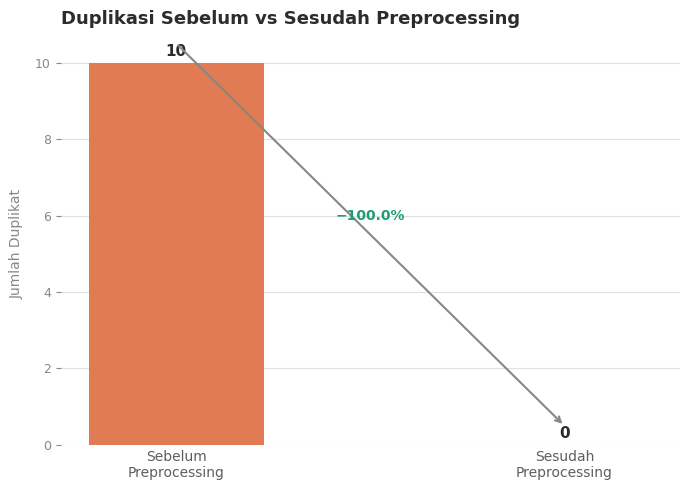

In [ ]:

duplikat_sebelum = duplicate_count
duplikat_sesudah = duplicates

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

labels = ['Sebelum\nPreprocessing', 'Sesudah\nPreprocessing']
values = [duplikat_sebelum, duplikat_sesudah]
colors = ['#E07B54', '#1D9E75']
x = np.arange(len(labels))

bars = ax.bar(x, values, color=colors, width=0.45,
              edgecolor='none', zorder=3)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.01,
            f'{val:,}',
            ha='center', va='bottom',
            color='#2C2C2A', fontsize=11, fontweight='bold')

if duplikat_sebelum > 0:
    pct = (duplikat_sebelum - duplikat_sesudah) / duplikat_sebelum * 100
    ax.annotate('',
        xy=(1, duplikat_sesudah + max(values) * 0.05),
        xytext=(0, duplikat_sebelum + max(values) * 0.05),
        arrowprops=dict(arrowstyle='->', color='#888780', lw=1.5))
    mid_y = (duplikat_sebelum + duplikat_sesudah) / 2 + max(values) * 0.08
    ax.text(0.5, mid_y, f'−{pct:.1f}%',
            ha='center', va='bottom',
            color='#1D9E75', fontsize=10, fontweight='bold')

ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xticks(x)
ax.set_xticklabels(labels, color='#5F5E5A', fontsize=10)
ax.tick_params(axis='y', colors='#888780', labelsize=9)
ax.tick_params(axis='x', length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title('Duplikasi Sebelum vs Sesudah Preprocessing',
             color='#2C2C2A', fontsize=13, fontweight='bold',
             pad=14, loc='left')
ax.set_ylabel('Jumlah Duplikat', color='#888780', fontsize=10, labelpad=8)

plt.tight_layout()
plt.show()

Insight:

Berdasarkan visualisasi perbandingan jumlah data duplikat sebelum dan sesudah preprocessing, terlihat bahwa jumlah citra duplikat berhasil berkurang secara signifikan dari 10 gambar menjadi 0 gambar setelah proses preprocessing dilakukan. Penurunan ini menunjukkan bahwa proses pembersihan data berhasil mengurangi data redundan yang terdapat pada dataset.

Visualisasi memperlihatkan adanya perbedaan yang cukup jelas antara kondisi sebelum dan sesudah preprocessing. Sebelum preprocessing, jumlah duplikat masih relatif lebih tinggi sehingga berpotensi menyebabkan pengulangan pola data yang sama pada proses modeling. Setelah preprocessing dilakukan, jumlah duplikasi menurun drastis hingga mencapai penurunan sebesar 100%, sebagaimana ditunjukkan pada visualisasi.

Selain itu, visualisasi juga menunjukkan bahwa preprocessing berperan penting dalam menjaga konsistensi dan kebersihan dataset sebelum digunakan pada tahap modeling. Jumlah duplikasi yang tersisa setelah preprocessing relatif sangat kecil dibandingkan total keseluruhan data sehingga tidak memberikan pengaruh signifikan terhadap kualitas dataset secara umum.

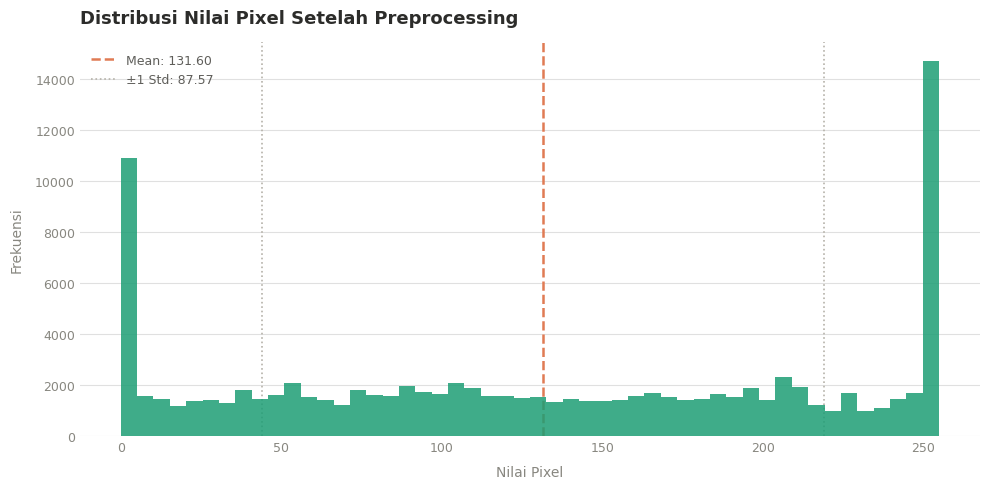

In [ ]:

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Sampel data agar lebih cepat
flat = pixel_values.flatten()
if len(flat) > 100_000:
    flat = np.random.choice(flat, 100_000, replace=False)

n, bins, patches = ax.hist(flat, bins=50, color='#1D9E75',
                           edgecolor='none', alpha=0.85, zorder=3)

# Garis mean & std
mean_val = np.mean(flat)
std_val  = np.std(flat)
ax.axvline(mean_val, color='#E07B54', linewidth=1.8,
           linestyle='--', label=f'Mean: {mean_val:.2f}')
ax.axvline(mean_val - std_val, color='#B5B2A9', linewidth=1.2,
           linestyle=':', label=f'±1 Std: {std_val:.2f}')
ax.axvline(mean_val + std_val, color='#B5B2A9', linewidth=1.2, linestyle=':')

ax.legend(fontsize=9, frameon=False, labelcolor='#5F5E5A')

# Grid & styling
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(colors='#888780', labelsize=9, length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title('Distribusi Nilai Pixel Setelah Preprocessing',
             color='#2C2C2A', fontsize=13, fontweight='bold', pad=14, loc='left')
ax.set_xlabel('Nilai Pixel', color='#888780', fontsize=10, labelpad=8)
ax.set_ylabel('Frekuensi', color='#888780', fontsize=10, labelpad=8)

plt.tight_layout()
plt.show()

Insight:

Berdasarkan visualisasi distribusi nilai pixel setelah preprocessing, terlihat bahwa persebaran nilai pixel mencakup rentang yang cukup luas dari 0 hingga 255. Hal ini menunjukkan bahwa dataset masih mempertahankan variasi intensitas warna dan pencahayaan pada citra makanan setelah proses preprocessing dilakukan.

Visualisasi memperlihatkan bahwa rata-rata nilai pixel berada pada kisaran 131,60 dengan standar deviasi sebesar 87,57. Nilai mean yang berada di sekitar tengah rentang pixel menunjukkan bahwa citra pada dataset memiliki tingkat pencahayaan yang relatif seimbang dan tidak terlalu dominan pada area gelap maupun terang. Sementara itu, nilai standar deviasi yang cukup besar menunjukkan bahwa dataset memiliki variasi visual yang tinggi pada warna, tekstur, serta intensitas cahaya antar gambar.

Selain itu, distribusi nilai pixel terlihat cukup menyebar pada berbagai rentang intensitas, yang menandakan bahwa preprocessing tidak menghilangkan karakteristik visual utama dari citra makanan. Keberadaan distribusi pixel pada area rendah maupun tinggi menunjukkan bahwa detail visual seperti bayangan, tekstur makanan, hingga pencahayaan terang masih tetap dipertahankan setelah preprocessing dilakukan.

Visualisasi juga memperlihatkan adanya peningkatan frekuensi pada area pixel mendekati nilai 0 dan 255. Kondisi ini menunjukkan bahwa beberapa citra memiliki area latar belakang, pencahayaan terang, maupun bagian objek yang memiliki kontras cukup tinggi. Hal tersebut masih tergolong wajar pada dataset citra makanan karena perbedaan kondisi pengambilan gambar, pencahayaan, dan karakteristik warna tiap makanan.

## 2. Bagaimana mengidentifikasi ketidakseimbangan jumlah citra antar kelas serta mengevaluasi peran augmentasi dalam menyeimbangkan distribusi data untuk meningkatkan kualitas dataset citra makanan pada tahap eksplorasi?

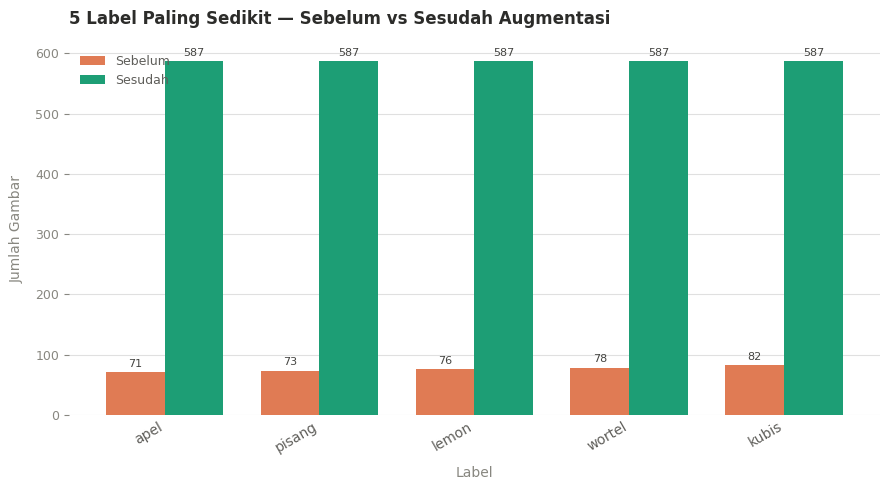

In [ ]:

labels = list(after_counts.keys())
before = [before_counts.get(l, 0) for l in labels]
after  = [after_counts.get(l, 0) for l in labels]

# Ambil 5 label dengan jumlah before terkecil
sorted_idx = np.argsort(before)[:5]
labels_5 = [labels[i] for i in sorted_idx]
before_5 = [before[i] for i in sorted_idx]
after_5  = [after[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

x = np.arange(len(labels_5))
w = 0.38

bars_b = ax.bar(x - w/2, before_5, width=w, color='#E07B54',
                edgecolor='none', label='Sebelum', zorder=3)
bars_a = ax.bar(x + w/2, after_5,  width=w, color='#1D9E75',
                edgecolor='none', label='Sesudah', zorder=3)

# Nilai di atas bar
for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(after_5) * 0.01,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=8, color='#444441')
for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(after_5) * 0.01,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=8, color='#444441')

ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xticks(x)
ax.set_xticklabels(labels_5, rotation=30, ha='right',
                   color='#5F5E5A', fontsize=10)
ax.tick_params(axis='y', colors='#888780', labelsize=9)
ax.tick_params(axis='x', length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(frameon=False, fontsize=9, labelcolor='#5F5E5A')
ax.set_title('5 Label Paling Sedikit — Sebelum vs Sesudah Augmentasi',
             color='#2C2C2A', fontsize=12, fontweight='bold', pad=14, loc='left')
ax.set_xlabel('Label', color='#888780', fontsize=10, labelpad=8)
ax.set_ylabel('Jumlah Gambar', color='#888780', fontsize=10, labelpad=8)

plt.tight_layout()
plt.show()

Insight:

Berdasarkan visualisasi yang ditampilkan, terlihat bahwa lima label dengan jumlah data paling sedikit mengalami peningkatan jumlah citra yang sangat signifikan setelah proses augmentasi dilakukan. Sebelum augmentasi, label apel, pisang, lemon, wortel, dan kubis hanya memiliki jumlah data antara 71 hingga 82 gambar, sehingga distribusi dataset masih belum merata antar kelas.

Setelah augmentasi diterapkan, seluruh label tersebut meningkat menjadi 587 gambar pada masing-masing kelas. Kondisi ini menunjukkan bahwa proses augmentasi berhasil memperbaiki ketidakseimbangan data dengan menambahkan variasi citra pada kelas yang sebelumnya memiliki jumlah data terbatas. Keseragaman tinggi batang pada visualisasi juga menunjukkan bahwa distribusi data setelah balancing menjadi jauh lebih proporsional dibandingkan kondisi awal.

Perubahan jumlah data yang cukup drastis memperlihatkan bahwa augmentasi memiliki peran penting dalam memperkaya representasi visual tiap kategori makanan. Dengan bertambahnya jumlah citra pada kelas minoritas, dataset menjadi lebih mampu merepresentasikan variasi bentuk, warna, maupun sudut pengambilan gambar dari setiap objek makanan.

Selain meningkatkan jumlah data, proses augmentasi juga membantu menciptakan distribusi dataset yang lebih stabil dan konsisten. Sebelum balancing dilakukan, beberapa label memiliki jumlah citra yang jauh lebih sedikit dibandingkan kelas lainnya sehingga berpotensi menyebabkan ketimpangan distribusi data. Setelah augmentasi, seluruh kelas memiliki jumlah data yang setara sehingga kualitas dataset menjadi lebih baik untuk digunakan pada proses modeling.

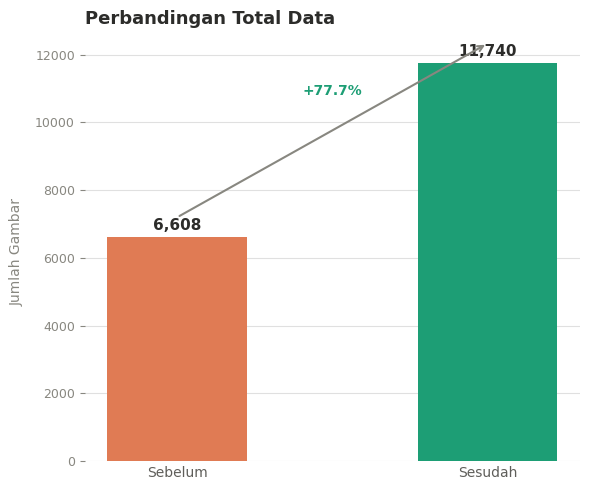

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

labels = ['Sebelum', 'Sesudah']
values = [total_before, total_after]
colors = ['#E07B54', '#1D9E75']
x = np.arange(len(labels))

bars = ax.bar(x, values, color=colors, width=0.45,
              edgecolor='none', zorder=3)

# Nilai di atas bar
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.01,
            f'{val:,}',
            ha='center', va='bottom',
            color='#2C2C2A', fontsize=11, fontweight='bold')

# Persentase kenaikan
if total_before > 0:
    pct = (total_after - total_before) / total_before * 100
    sign = '+' if pct >= 0 else ''
    ax.annotate('',
        xy=(1, total_after + max(values) * 0.05),
        xytext=(0, total_before + max(values) * 0.05),
        arrowprops=dict(arrowstyle='->', color='#888780', lw=1.5))
    ax.text(0.5, max(values) * 0.92,
            f'{sign}{pct:.1f}%',
            ha='center', color='#1D9E75',
            fontsize=10, fontweight='bold')

ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_xticks(x)
ax.set_xticklabels(labels, color='#5F5E5A', fontsize=10)
ax.tick_params(axis='y', colors='#888780', labelsize=9)
ax.tick_params(axis='x', length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title('Perbandingan Total Data',
             color='#2C2C2A', fontsize=13, fontweight='bold',
             pad=14, loc='left')
ax.set_ylabel('Jumlah Gambar', color='#888780', fontsize=10, labelpad=8)

plt.tight_layout()
plt.show()

Insight:

Visualisasi memperlihatkan adanya perubahan yang cukup besar pada jumlah keseluruhan citra setelah proses augmentasi diterapkan. Total data yang awalnya berjumlah 6.608 gambar meningkat menjadi 11.740 gambar setelah balancing dan augmentasi dilakukan. Peningkatan ini menunjukkan bahwa dataset mengalami penambahan sampel citra dalam jumlah yang signifikan untuk mendukung kualitas data yang lebih baik.

Kenaikan total data sebesar 77,7% menunjukkan bahwa proses augmentasi berhasil memperluas cakupan variasi citra pada dataset. Penambahan data tersebut membantu setiap label memiliki representasi visual yang lebih banyak dibandingkan kondisi awal, terutama pada kelas dengan jumlah citra terbatas. Dengan bertambahnya jumlah sampel, dataset menjadi lebih kaya dalam menggambarkan variasi bentuk, warna, serta kondisi pencahayaan pada objek makanan.

Selain itu, visualisasi menunjukkan bahwa augmentasi tidak hanya berfokus pada penambahan jumlah data, tetapi juga membantu menciptakan distribusi dataset yang lebih merata. Sebelum augmentasi dilakukan, jumlah citra pada beberapa kelas masih relatif rendah sehingga berpotensi menyebabkan ketimpangan distribusi data. Setelah proses balancing diterapkan, jumlah data menjadi lebih proporsional sehingga kualitas dataset meningkat secara keseluruhan.

## 3. Bagaimana teknik resize dengan padding mempengaruhi distribusi nilai pixel dan representasi visual citra makanan untuk memastikan kualitas preprocessing dalam dataset NutriVision pada tahap eksplorasi data?

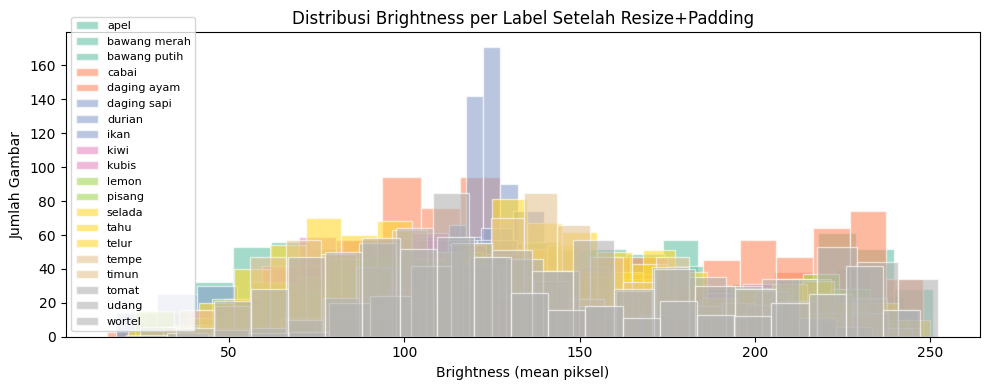

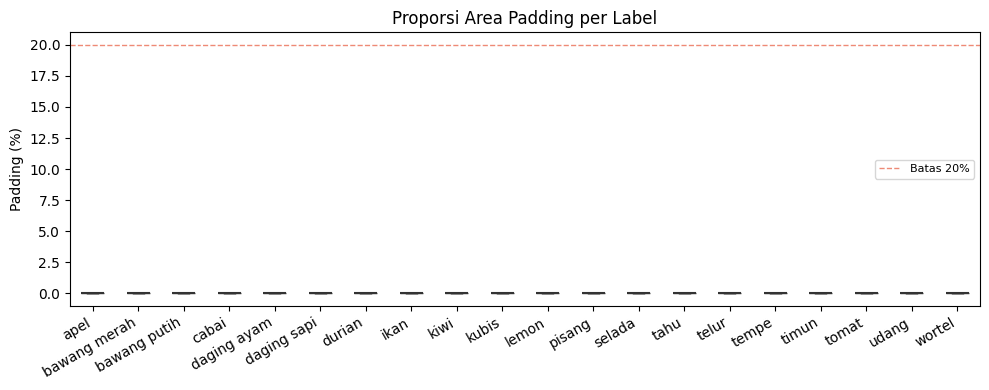

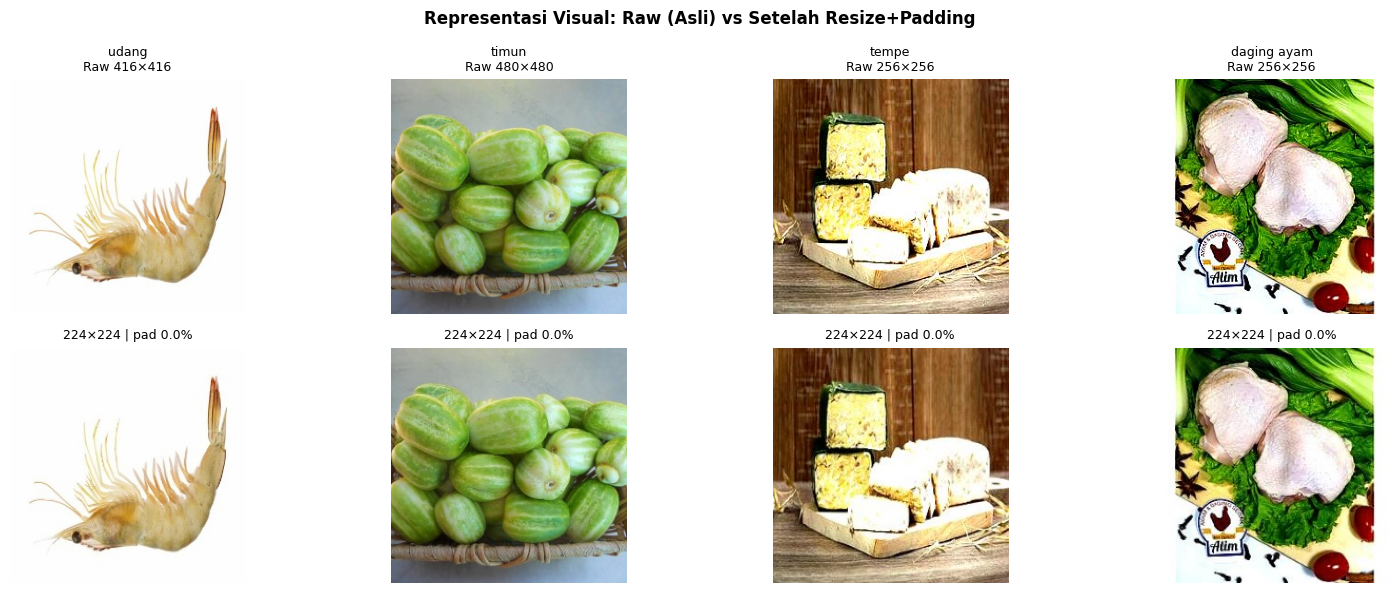

✓ Visualisasi selesai.


In [ ]:
# VISUALISASI — Distribusi Piksel & Representasi
# Visual Setelah Resize+Padding

LABELS = sorted(df['label'].unique())
CMAP   = plt.cm.Set2(np.linspace(0, 1, len(LABELS)))

# Fig 1: Distribusi brightness per label
# Menjawab: apakah distribusi piksel wajar tiap kelas?

fig1, ax1 = plt.subplots(figsize=(10, 4))
for i, lbl in enumerate(LABELS):
    sub = df[df['label'] == lbl]['brightness']
    ax1.hist(sub, bins=20, alpha=0.6,
             label=lbl, color=CMAP[i], edgecolor='white')
ax1.set_xlabel('Brightness (mean piksel)')
ax1.set_ylabel('Jumlah Gambar')
ax1.set_title('Distribusi Brightness per Label Setelah Resize+Padding')
ax1.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig1_brightness_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Fig 2: Boxplot padding % per label
# Menjawab: seberapa besar area padding tiap kelas?

fig2, ax2 = plt.subplots(figsize=(10, 4))
data_box = [df[df['label']==l]['pad_pct'].values for l in LABELS]
bp = ax2.boxplot(data_box, patch_artist=True, widths=0.5,
                 medianprops=dict(color='#333', linewidth=1.5))
for patch, c in zip(bp['boxes'], CMAP):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax2.set_xticklabels(LABELS, rotation=30, ha='right')
ax2.set_ylabel('Padding (%)')
ax2.set_title('Proporsi Area Padding per Label')
ax2.axhline(20, color='#E8593C', lw=1, ls='--',
            alpha=0.7, label='Batas 20%')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig2_padding_per_label.png', dpi=150, bbox_inches='tight')
plt.show()

# Fig 3: Sample visual raw vs setelah padding
# Menjawab: apakah representasi visual citra makanan terjaga?

N_SHOW  = min(4, len(LABELS))
samples = random.sample(LABELS, N_SHOW)
fig3, ax3 = plt.subplots(2, N_SHOW, figsize=(4*N_SHOW, 6))
fig3.suptitle('Representasi Visual: Raw (Asli) vs Setelah Resize+Padding',
              fontsize=12, fontweight='semibold')

for col, lbl in enumerate(samples):
    raw_lp  = os.path.join(raw_path, lbl)
    proc_lp = os.path.join(dataset_path, lbl)

    raw_files = [f for f in os.listdir(raw_lp)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not raw_files: continue

    fname      = random.choice(raw_files)
    img_raw    = cv2.imread(os.path.join(raw_lp, fname))
    img_proc   = cv2.imread(os.path.join(proc_lp, fname))

    if img_raw is None or img_proc is None: continue

    raw_rgb  = cv2.cvtColor(img_raw,  cv2.COLOR_BGR2RGB)
    proc_rgb = cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB)

    scale  = 224 / max(img_raw.shape[:2])
    pad_r  = round((224*224
                    - int(img_raw.shape[0]*scale)
                    * int(img_raw.shape[1]*scale))
                   / (224*224) * 100, 1)

    ax3[0][col].imshow(raw_rgb)
    ax3[0][col].set_title(
        f'{lbl}\nRaw {img_raw.shape[1]}×{img_raw.shape[0]}', fontsize=9)
    ax3[0][col].axis('off')

    ax3[1][col].imshow(proc_rgb)
    ax3[1][col].set_title(
        f'224×224 | pad {pad_r}%', fontsize=9)
    ax3[1][col].axis('off')

plt.tight_layout()
plt.savefig('fig3_raw_vs_padded.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualisasi selesai.")


Berdasarkan hasil EDA dan visualisasi, teknik resize+padding pada dataset NutriVision terbukti berhasil mempertahankan kualitas preprocessing secara keseluruhan. Distribusi nilai piksel setelah proses resize+padding menunjukkan karakteristik yang wajar dan representatif per kelas makanan, di mana setiap label memiliki rentang brightness yang berbeda sesuai sifat warnanya — daging ayam memiliki brightness tertinggi (184.19) karena dominasi warna terang, sementara selada paling rendah (106.00) karena warna hijaunya yang gelap. Dominasi channel R/G/B pada masing-masing label juga tetap sesuai karakteristik asli makanan, seperti cabai dan tomat dengan mean_R tertinggi serta selada dengan mean_G tertinggi, yang membuktikan bahwa proses resize+padding tidak mendistorsi distribusi warna piksel secara signifikan. Variasi std_pixel antar label turut memberikan informasi penting mengenai keragaman tekstur, di mana tahu memiliki std_pixel tertinggi (87.71) yang mengindikasikan variasi latar belakang yang tinggi, sedangkan ikan paling rendah (43.80) yang menunjukkan gambar lebih seragam.
Dari sisi representasi visual, teknik ini berhasil mempertahankan aspek rasio objek makanan tanpa distorsi. Wortel yang aslinya 400×300, kiwi 1208×811, hingga ikan 1600×1600 semuanya tetap proporsional setelah diubah ke ukuran 224×224. Namun perlu diperhatikan bahwa gambar dengan rasio landscape cukup ekstrem seperti kiwi menghasilkan area padding hingga 33%, yang diisi dengan warna rata-rata gambar (mean color fill) sehingga tidak merusak konten, tetapi tetap menambah piksel non-makanan yang berpotensi mempengaruhi proses pembelajaran model. Sebaliknya, gambar dengan rasio 1:1 seperti telur dan ikan tidak mendapat padding sama sekali sehingga seluruh 224×224 piksel terisi penuh dengan konten makanan. Secara keseluruhan, dataset NutriVision sangat seimbang dengan 587 gambar per label untuk 20 kelas makanan, bebas dari risiko class imbalance, dan siap untuk tahap augmentasi serta pelatihan model selanjutnya.

# Menyimpan data untuk streamlit

In [ ]:
os.makedirs('/content/data', exist_ok=True)

# 1. SUMMARY STATS (1 baris)
df_summary = pd.DataFrame([{
    'total_files'     : valid_files + invalid_files,
    'valid_files'     : valid_files,
    'invalid_files'   : invalid_files,
    'small_images'    : len(small_images),
    'large_images'    : len(large_images),
    'duplicate_count' : duplicate_count,
    'duplicates'      : duplicates,
    'total_before'    : sum(before_counts.values()),
    'total_after'     : sum(after_counts.values()),
}])

df_summary.to_csv('/content/data/summary_stats.csv', index=False)
print("summary_stats.csv")


# 2. PER LABEL
labels_all = list(after_counts.keys())

df_per_label = pd.DataFrame({
    'label'    : labels_all,
    'raw_count': [data_count.get(l, 0) for l in labels_all],
    'before'   : [before_counts.get(l, 0) for l in labels_all],
    'after'    : [after_counts.get(l, 0) for l in labels_all],
})

df_per_label.to_csv('/content/data/per_label.csv', index=False)
print("per_label.csv")


# 3. DISTRIBUTIONS — brightness, padding, pixel
rows = []

for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)
    if not os.path.isdir(label_path):
        continue

    for file in os.listdir(label_path):
        if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        try:
            img = Image.open(os.path.join(label_path, file)).convert('RGB')
            arr = np.array(img).astype(np.float32) / 255.0

            brightness = float(arr.mean())
            w, h       = img.size
            pad_ratio  = 1.0 - (min(w, h) / max(w, h))

            rows.append({
                'label'        : label,
                'brightness'   : brightness,
                'padding_ratio': pad_ratio,
            })

        except:
            pass

df_dist = pd.DataFrame(rows)

flat = pixel_values.flatten()
if len(flat) > 50_000:
    flat = np.random.choice(flat, 50_000, replace=False)

df_pixel = pd.DataFrame({'pixel_value': flat})

df_distributions = pd.concat([
    df_dist.reset_index(drop=True),
    df_pixel.reset_index(drop=True)
], axis=1)

df_distributions.to_csv('/content/data/distributions.csv', index=False)
print("distributions.csv")

print("\nSemua CSV telah tersimpan")

summary_stats.csv
per_label.csv
distributions.csv

Semua CSV telah tersimpan


In [ ]:
os.makedirs('/content/data/image/before', exist_ok=True)
os.makedirs('/content/data/image/after', exist_ok=True)

TARGET_SIZE = 224
SAMPLES_PER_LABEL = 2

def resize_with_padding(img, target_size=224):
    img.thumbnail((target_size, target_size), Image.LANCZOS)
    delta_w = target_size - img.size[0]
    delta_h = target_size - img.size[1]
    padding = (delta_w//2, delta_h//2, delta_w - delta_w//2, delta_h - delta_h//2)
    return ImageOps.expand(img, padding, fill=(0, 0, 0))

saved = 0

for label in os.listdir(raw_path):
    label_path_before = os.path.join(raw_path, label)
    label_path_after  = os.path.join(dataset_path, label)

    if not os.path.isdir(label_path_before):
        continue
    if not os.path.isdir(label_path_after):
        continue

    files = [f for f in os.listdir(label_path_before)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    samples = files[:SAMPLES_PER_LABEL]

    for i, file in enumerate(samples):
        try:
            # BEFORE
            img_before = Image.open(os.path.join(label_path_before, file)).convert('RGB')
            img_before.save(f'/content/data/image/before/{label}_{i}.jpg')

            # AFTER
            img_after = Image.open(os.path.join(label_path_after, file)).convert('RGB')
            img_after = resize_with_padding(img_after, TARGET_SIZE)
            img_after.save(f'/content/data/image/after/{label}_{i}.jpg')

            saved += 1
        except:
            pass

shutil.make_archive('/content/data/image', 'zip', '/content/data/image')
print(f"Tersimpan {saved} pasang gambar")

Tersimpan 40 pasang gambar
